In [3]:
import pandas as pd
import numpy as np
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots

import nbformat 
#import kaleido

In [20]:
# cargo CSV precio del bitcoin
btc = pd.read_csv("../data/btc.csv")
# elimino fila 0, donde aparece btc-usd
btc = btc[btc["Close"] != "BTC-USD"]

# convierto Date a datetime
btc['Date'] = pd.to_datetime(btc['Date'], errors='coerce')

# convierto las demás columnas a numéricas (float)
numeric_cols = ['Close', 'High', 'Low', 'Open', 'Volume']
for col in numeric_cols:
    btc[col] = pd.to_numeric(btc[col], errors='coerce')

# reviso cómo quedaron
btc.info()
btc.isnull().sum()

# primera descripcion
btc.describe()
btc.tail()

<class 'pandas.core.frame.DataFrame'>
Index: 3127 entries, 1 to 3127
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3127 non-null   datetime64[ns]
 1   Close   3127 non-null   float64       
 2   Open    3127 non-null   float64       
 3   High    3127 non-null   float64       
 4   Low     3127 non-null   float64       
 5   Volume  3127 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 171.0 KB


,Date,Close,Open,High,Low,Volume
3123,2026-08-20,73032.757812,69268.250000,73369.804688,68867.531250,55444322363
3124,2026-08-21,78335.187500,73031.085938,79463.710938,73011.414062,74478039014
3125,2026-08-22,77083.414062,78332.554688,78801.148438,76526.710938,42131959963
3126,2026-08-23,77755.265625,77082.843750,78036.867188,75624.945312,31158396908
3127,2026-08-24,78858.929688,77727.617188,79891.304688,76838.726562,56741580800


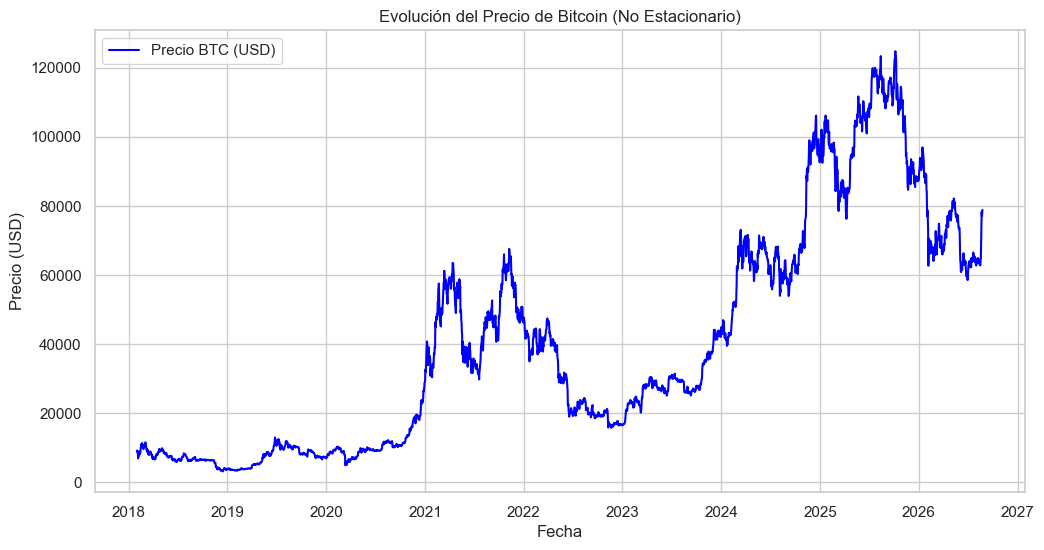

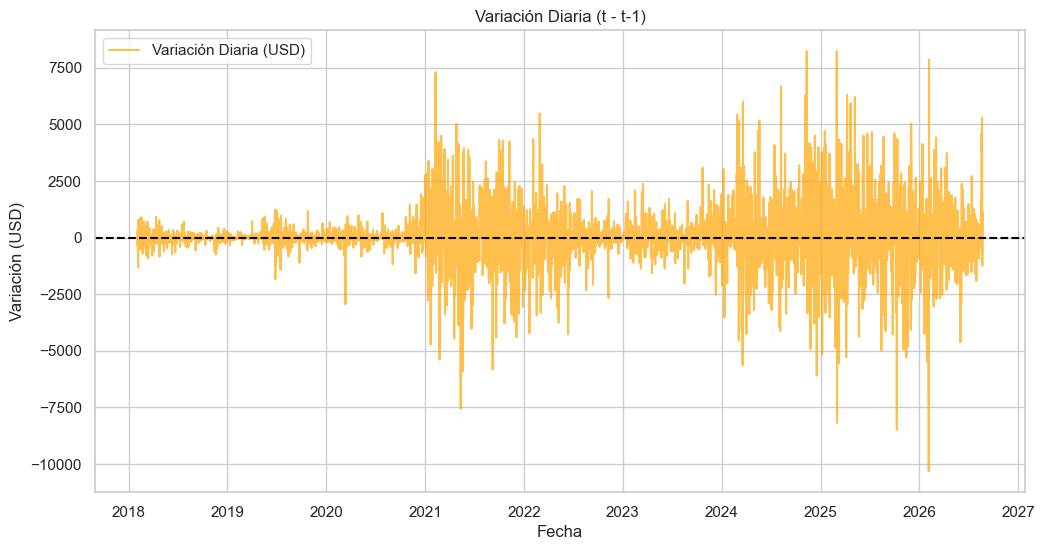

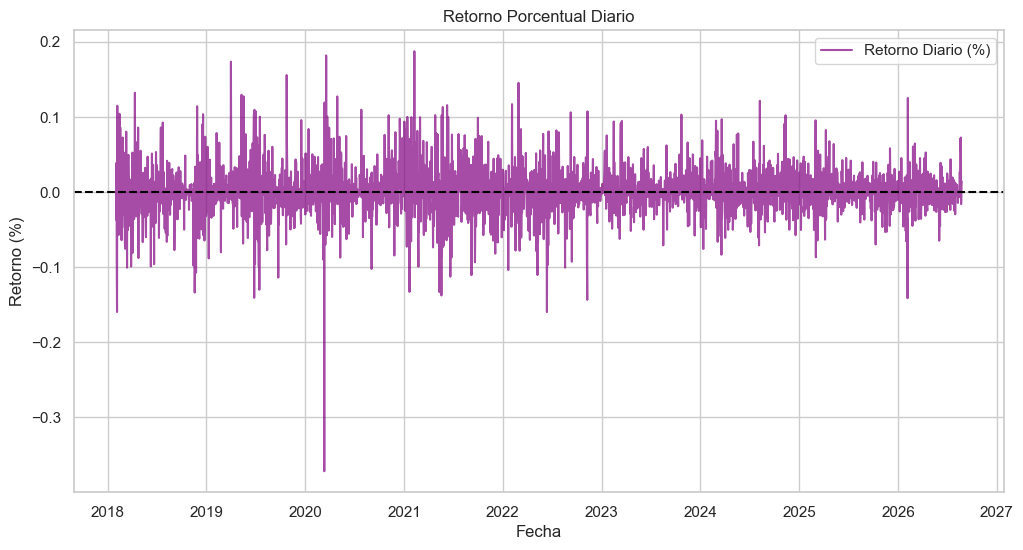

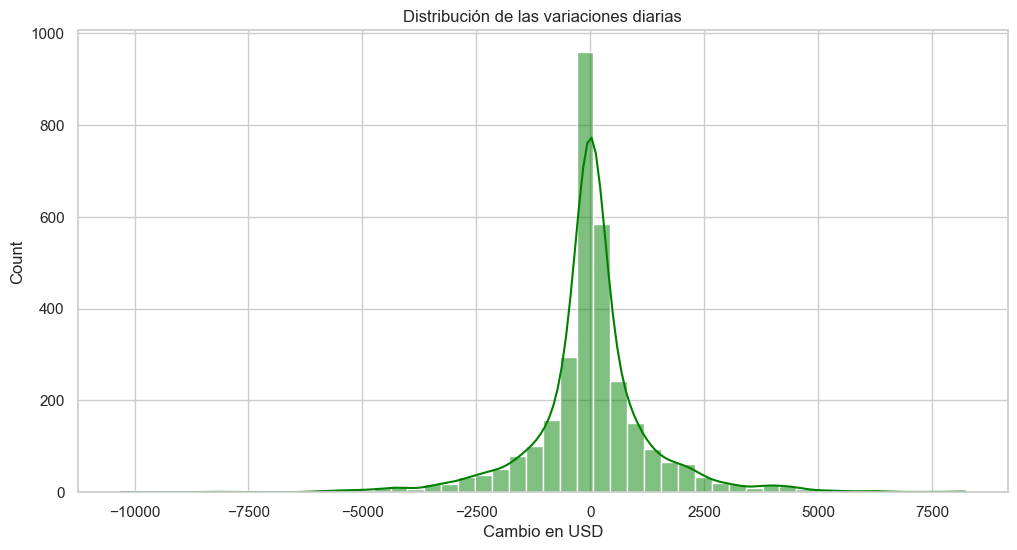

Estadísticas de la variable objetivo (Variación Diaria):
count     3126.000000
mean        22.293151
std       1345.217548
min     -10317.605469
25%       -341.462402
50%          6.878662
75%        390.972656
max       8227.296875
Name: Diff_USD, dtype: float64


In [23]:
# Configuración de estilo para gráficos académicos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

if isinstance(btc.columns, pd.MultiIndex):
    btc = btc.xs('Close', level=0, axis=1, drop_level=False)

# Uso la fecha real como eje X en vez del índice posicional
data = btc[['Date', 'Close']].copy()

# 2. GENERACIÓN DEL TARGET Y DIFERENCIACIÓN
# Diferencia (t - t-1): Cuánto cambió el precio en USD respecto a ayer
data['Diff_USD'] = data['Close'].diff()

# Retorno porcentual (más robusto para ML financiero, evita el sesgo de la escala en USD)
data['Pct_Change'] = data['Close'].pct_change()

# 3. VISUALIZACIÓN DEL TARGET (EDA)
# Gráfico A: Precio de Cierre
plt.figure()
plt.plot(data['Date'], data['Close'], label='Precio BTC (USD)', color='blue')
plt.title('Evolución del Precio de Bitcoin (No Estacionario)')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.show()

# Gráfico B: Diferencias diarias
# Esto nos muestra la VOLATILIDAD y qué tan difícil es predecir
plt.figure()
plt.plot(data['Date'], data['Diff_USD'], label='Variación Diaria (USD)', color='orange', alpha=0.7)
plt.title('Variación Diaria (t - t-1)')
plt.xlabel('Fecha')
plt.ylabel('Variación (USD)')
plt.axhline(0, color='black', linestyle='--')
plt.legend()
plt.show()

# Gráfico C: Retorno porcentual diario
plt.figure()
plt.plot(data['Date'], data['Pct_Change'], label='Retorno Diario (%)', color='purple', alpha=0.7)
plt.title('Retorno Porcentual Diario')
plt.xlabel('Fecha')
plt.ylabel('Retorno (%)')
plt.axhline(0, color='black', linestyle='--')
plt.legend()
plt.show()

# Gráfico D: Distribución de los cambios
plt.figure()
sns.histplot(data['Diff_USD'].dropna(), bins=50, kde=True, color='green')
plt.title('Distribución de las variaciones diarias')
plt.xlabel('Cambio en USD')
plt.show()

# 4. ESTADÍSTICAS BÁSICAS
print("Estadísticas de la variable objetivo (Variación Diaria):")
print(data['Diff_USD'].describe())

## Observaciones

**Gráfico A - Precio de Cierre:** La serie es claramente **no estacionaria**: muestra una tendencia creciente de fondo, interrumpida por grandes ciclos alcistas y bajistas (2021, 2022, 2024-2026), pasando de valores cercanos a $5.000-10.000 en 2018 a superar los $120.000 en 2025. Al no tener media ni varianza constante en el tiempo, esta variable no es apta para modelar directamente y justifica trabajar con las diferencias/retornos.

**Gráfico B - Variación Diaria (USD):** Se observa **heterocedasticidad: los datos tienen  una dispersión variable y afectando la confianza en los resultados**: la magnitud de las variaciones diarias en dólares crece a medida que el precio del BTC aumenta (oscilaciones de apenas ±1.000 USD en 2018-2020 contra picos de +-8.000-10.000 USD en 2024-2026). Esto es esperable, ya que a mayor precio base, mayor es el movimiento absoluto en USD para un mismo movimiento porcentual.

**Gráfico C - Retorno Porcentual Diario:** Al normalizar por el precio (retorno %), la volatilidad relativa se mantiene mucho más **estable a lo largo del tiempo** que en el Gráfico B, con retornos diarios típicamente entre -10% y +15%. Se destaca un outlier extremo cercano a -35% en 2020 (coincide con el crash de mercado de marzo 2020 por COVID-19). Esto confirma que el retorno porcentual es una variable más comparable entre distintos períodos y más adecuada como target para un modelo de ML que la variación en USD.

**Gráfico D - Distribución de las variaciones diarias:** La distribución está centrada en 0, con forma **leptocúrtica** (pico alto y colas pesadas): la mayoría de los días tienen variaciones pequeñas, pero existen outliers de hasta +-10.000 USD. Esto es típico de series financieras y indica que los modelos deberán lidiar con eventos extremos poco frecuentes pero de alto impacto.

**Estadísticas de `Diff_USD`:** La media (~22.29 USD) es prácticamente 0 comparada con el desvío estándar (~1.345 USD), y la mediana (6.88 USD aprox.) también es cercana a 0. Esto sugiere que, en el corto plazo, el precio del BTC se comporta de forma similar a un **random walk**, donde la dirección del próximo movimiento es difícil de predecir únicamente a partir de la serie de precios.


In [24]:
# Agrego columnas calculadas
btc['Daily_Change'] = btc['Close'] - btc['Open'] #Diferencia entre el precio de cierre y de apertura del día.
btc['Volatility'] = btc['High'] - btc['Low'] #Diferencia entre el valor máximo y mínimo del día.
btc['Pct_Change'] = btc['Close'].pct_change() #variación porcentual del precio de cierre respecto al día anterior.
btc['Volume_Change_pct'] = btc["Volume"].pct_change() #Variación porcentual del volumen de transacciones respecto al día anterior.
btc['SMA_7'] = btc["Close"].rolling(7).mean() #Promedio/media móvil a 7 días. Tendencia a corto plazo.
btc['SMA_30'] = btc["Close"].rolling(30).mean() #Promedio/media móvil a 30 días. Tendencia a largo plazo.
btc["Rolling_volatility_7"] = btc["Pct_Change"].rolling(7).std() #desviacion los ultimos 7 dias
btc["Rolling_volatility_30"] = btc["Pct_Change"].rolling(30).std() #desviacion los ultimos 30 dias

lags = [1, 2, 3, 7]  # días anteriores

# Crear las columnas de lags
for lag in lags:
    btc[f'BTC_Close_t-{lag}'] = btc['Close'].shift(lag)

btc.tail(10)

,Date,Close,Open,High,Low,Volume,Daily_Change,Volatility,Pct_Change,Volume_Change_pct,SMA_7,SMA_30,Rolling_volatility_7,Rolling_volatility_30,BTC_Close_t-1,BTC_Close_t-2,BTC_Close_t-3,BTC_Close_t-7
3118,2026-08-15,63024.320312,62974.335938,63119.132812,62850.960938,10033057106,49.984375,268.171875,0.000774,-0.505275,63587.409598,64219.341797,0.005309,0.011411,62975.593750,63402.171875,63402.433594,64904.687500
3119,2026-08-16,62818.652344,63023.421875,63310.777344,62648.574219,9078986635,-204.769531,662.203125,-0.003263,-0.095093,63297.947545,64183.314844,0.005140,0.011417,63024.320312,62975.593750,63402.171875,64844.886719
3120,2026-08-17,64506.253906,62819.378906,64547.847656,62687.101562,21555405073,1686.875000,1860.746094,0.026865,1.374208,63383.042969,64173.636589,0.011561,0.012194,62818.652344,63024.320312,62975.593750,63910.585938
3121,2026-08-18,64680.710938,64506.523438,64987.710938,63980.324219,18728001793,174.187500,1007.386719,0.002704,-0.131169,63544.305246,64173.300130,0.011142,0.012200,64506.253906,62818.652344,63024.320312,63551.875000
3122,2026-08-19,69266.187500,64680.046875,69996.953125,64111.070312,46228098443,4586.140625,5885.882812,0.070894,1.468395,64381.984375,64307.838802,0.027756,0.017747,64680.710938,64506.253906,62818.652344,63402.433594
3123,2026-08-20,73032.757812,69268.250000,73369.804688,68867.531250,55444322363,3764.507812,4502.273438,0.054378,0.199364,65757.782366,64525.426562,0.030927,0.019930,69266.187500,64680.710938,64506.253906,63402.171875
3124,2026-08-21,78335.187500,73031.085938,79463.710938,73011.414062,74478039014,5304.101562,6452.296875,0.072603,0.343294,67952.010045,64933.239583,0.033579,0.023507,73032.757812,69266.187500,64680.710938,62975.593750
3125,2026-08-22,77083.414062,78332.554688,78801.148438,76526.710938,42131959963,-1249.140625,2274.437500,-0.015980,-0.434304,69960.452009,65334.526302,0.036644,0.023507,78335.187500,73032.757812,69266.187500,63024.320312
3126,2026-08-23,77755.265625,77082.843750,78036.867188,75624.945312,31158396908,672.421875,2411.921875,0.008716,-0.260457,72094.253906,65789.751953,0.035092,0.023190,77083.414062,78335.187500,73032.757812,62818.652344
3127,2026-08-24,78858.929688,77727.617188,79891.304688,76838.726562,56741580800,1131.312500,3052.578125,0.014194,0.821069,74144.636161,66274.655859,0.035690,0.023220,77755.265625,77083.414062,78335.187500,64506.253906


In [25]:
# Cargar el índice Fear and Greed
fear_greed = pd.read_csv("../data/fear_greed.csv")

# fear_greed = fear_greed.drop(columns=['time_until_update'])
fear_greed = fear_greed.rename(columns={'date': 'Date'})

# Convertir a datetime desde formato día-mes-año
fear_greed['Date'] = pd.to_datetime(
    fear_greed['Date'].astype(str).str.strip(),
    format='%d-%m-%Y',
    errors='coerce'
)

fear_greed['Date'] = fear_greed['Date'].dt.tz_localize(None)
fear_greed['Date'] = fear_greed['Date'].dt.normalize()
fear_greed = fear_greed.sort_values(by='Date', ascending=True)
fear_greed = fear_greed.reset_index(drop=True)

# Mostrar información y primeros registros
fear_greed.describe()
fear_greed.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3123 entries, 0 to 3122
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                3123 non-null   datetime64[ns]
 1   fng_value           3123 non-null   float64       
 2   fng_classification  3123 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 73.3+ KB


In [26]:
# Agrego columnas calculadas:
fear_greed['fng_diff_day'] = fear_greed['fng_value'].diff()
fear_greed['fng_SMA_7'] = fear_greed['fng_value'].rolling(7).mean()
fear_greed['fng_SMA_30'] = fear_greed['fng_value'].rolling(30).mean()
fear_greed['fng_trend'] = fear_greed['fng_SMA_7'] - fear_greed['fng_SMA_30']
fear_greed.tail(10)

,Date,fng_value,fng_classification,fng_diff_day,fng_SMA_7,fng_SMA_30,fng_trend
3113,2026-08-15,34.0,Fear,5.0,29.857143,28.233333,1.623810
3114,2026-08-16,34.0,Fear,0.0,30.285714,28.466667,1.819048
3115,2026-08-17,31.0,Fear,-3.0,30.428571,28.666667,1.761905
3116,2026-08-18,41.0,Fear,10.0,32.142857,29.100000,3.042857
3117,2026-08-19,46.0,Fear,5.0,34.857143,29.666667,5.190476
3118,2026-08-20,62.0,Greed,16.0,39.571429,30.900000,8.671429
3119,2026-08-21,72.0,Greed,10.0,45.714286,32.200000,13.514286
3120,2026-08-22,71.0,Greed,-1.0,51.000000,33.533333,17.466667
3121,2026-08-23,66.0,Greed,-5.0,55.571429,34.800000,20.771429
3122,2026-08-24,73.0,Greed,7.0,61.571429,36.333333,25.238095


In [27]:
full_data = pd.merge_asof(btc.sort_values('Date'),
                          fear_greed.sort_values('Date'),
                          on = 'Date',
                          direction='backward')
full_data.tail(10)

,Date,Close,Open,High,Low,Volume,Daily_Change,Volatility,Pct_Change,Volume_Change_pct,...,BTC_Close_t-1,BTC_Close_t-2,BTC_Close_t-3,BTC_Close_t-7,fng_value,fng_classification,fng_diff_day,fng_SMA_7,fng_SMA_30,fng_trend
3117,2026-08-15,63024.320312,62974.335938,63119.132812,62850.960938,10033057106,49.984375,268.171875,0.000774,-0.505275,...,62975.593750,63402.171875,63402.433594,64904.687500,34.0,Fear,5.0,29.857143,28.233333,1.623810
3118,2026-08-16,62818.652344,63023.421875,63310.777344,62648.574219,9078986635,-204.769531,662.203125,-0.003263,-0.095093,...,63024.320312,62975.593750,63402.171875,64844.886719,34.0,Fear,0.0,30.285714,28.466667,1.819048
3119,2026-08-17,64506.253906,62819.378906,64547.847656,62687.101562,21555405073,1686.875000,1860.746094,0.026865,1.374208,...,62818.652344,63024.320312,62975.593750,63910.585938,31.0,Fear,-3.0,30.428571,28.666667,1.761905
3120,2026-08-18,64680.710938,64506.523438,64987.710938,63980.324219,18728001793,174.187500,1007.386719,0.002704,-0.131169,...,64506.253906,62818.652344,63024.320312,63551.875000,41.0,Fear,10.0,32.142857,29.100000,3.042857
3121,2026-08-19,69266.187500,64680.046875,69996.953125,64111.070312,46228098443,4586.140625,5885.882812,0.070894,1.468395,...,64680.710938,64506.253906,62818.652344,63402.433594,46.0,Fear,5.0,34.857143,29.666667,5.190476
3122,2026-08-20,73032.757812,69268.250000,73369.804688,68867.531250,55444322363,3764.507812,4502.273438,0.054378,0.199364,...,69266.187500,64680.710938,64506.253906,63402.171875,62.0,Greed,16.0,39.571429,30.900000,8.671429
3123,2026-08-21,78335.187500,73031.085938,79463.710938,73011.414062,74478039014,5304.101562,6452.296875,0.072603,0.343294,...,73032.757812,69266.187500,64680.710938,62975.593750,72.0,Greed,10.0,45.714286,32.200000,13.514286
3124,2026-08-22,77083.414062,78332.554688,78801.148438,76526.710938,42131959963,-1249.140625,2274.437500,-0.015980,-0.434304,...,78335.187500,73032.757812,69266.187500,63024.320312,71.0,Greed,-1.0,51.000000,33.533333,17.466667
3125,2026-08-23,77755.265625,77082.843750,78036.867188,75624.945312,31158396908,672.421875,2411.921875,0.008716,-0.260457,...,77083.414062,78335.187500,73032.757812,62818.652344,66.0,Greed,-5.0,55.571429,34.800000,20.771429
3126,2026-08-24,78858.929688,77727.617188,79891.304688,76838.726562,56741580800,1131.312500,3052.578125,0.014194,0.821069,...,77755.265625,77083.414062,78335.187500,64506.253906,73.0,Greed,7.0,61.571429,36.333333,25.238095


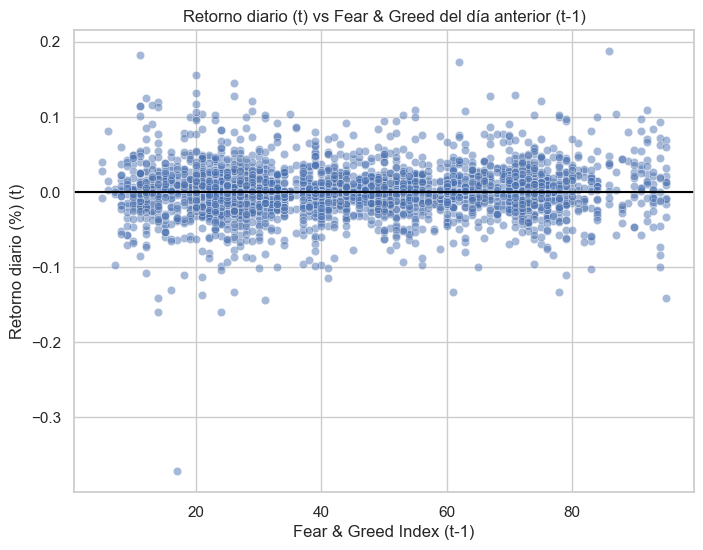

In [28]:
full_data['fng_value_lag1'] = full_data['fng_value'].shift(1) #Dia anteorior
scatter_data = full_data[['Pct_Change', 'fng_value_lag1', 'fng_classification']].dropna()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=scatter_data, x='fng_value_lag1', y='Pct_Change', alpha=0.5)
plt.axhline(0, color='black', linestyle='-')
plt.title('Retorno diario (t) vs Fear & Greed del día anterior (t-1)')
plt.xlabel('Fear & Greed Index (t-1)')
plt.ylabel('Retorno diario (%) (t)')
plt.show()

Al relacionar el retorno diario (que es la variación porcentual del precio de cierre ('Close') respecto al dia anterior) y el indice F&G. Nos indica que NO hay una relación lineal clara y que los puntos se concentrar al rededor de (+- 0.5). No encuentro una relación de tendencia al analizarlo.

In [ ]:
# Mapeo de colores para las categorías del Fear & Greed
colors = {
    'Extreme Fear': 'darkblue',
    'Fear': 'blue',
    'Neutral': 'orange',
    'Greed': 'red',
    'Extreme Greed': 'darkred'
}

df_plot = full_data[['Date', 'Close', 'fng_value', 'fng_classification']].dropna()

fig = go.Figure()

# Línea de precio de Bitcoin
fig.add_trace(go.Scatter(
    x=df_plot['Date'],
    y=df_plot['Close'],
    mode='lines',
    name='Precio BTC',
    line=dict(color='black', width=2)
))

# Marcadores del Fear & Greed
fig.add_trace(go.Scatter(
    x=df_plot['Date'],
    y=df_plot['fng_value'],
    mode='markers',
    name='Fear & Greed',
    marker=dict(color=[colors[c] for c in df_plot['fng_classification']], size=10),
    text=df_plot['fng_classification'],
    hoverinfo='text+y',
))

# Layout
fig.update_layout(
    title='Precio de Bitcoin vs Fear & Greed',
    yaxis=dict(title='Precio BTC', side='left'),
    yaxis2=dict(title='Fear & Greed Value', overlaying='y', side='right', range=[0,100]),
    legend=dict(x=0.01, y=0.99)
)

fig.show()

## Fear and Greed (índice de miedo y codicia)  
Es una medida del sentimiento del mercado, creada para el mercado de acciones, pero que también se aplica a criptomonedas. Su objetivo es reflejar si los inversores están dominados por el miedo o por la codicia, lo que puede influir en sus decisiones de compra o venta.  
El índice va de 0 a 100:  
- 0-25: Miedo extremo
- 26-49: Miedo
- 50-74: Codicia
- 75-100: Codicia extrema  

El gráfico refleja este patrón, puntos azules (Fear/Extreme Fear) coinciden con caídas del precio del bitcoin, y puntos rojos (Greed/Extreme Greed) coincide con picos de subida en el precio.

# Halving de Bitcoin

El halving es un evento programado que reduce a la mitad la recompensa por minar bloques, aproximadamente cada 4 años.

## Impacto en BTC

- **Menor oferta nueva:** ingresan menos bitcoins al mercado, lo que aumenta la escasez.
- **Efecto en el precio:** si la demanda se mantiene o crece, esa menor oferta puede impulsar subas en el precio.
- **Expectativa del mercado:** suele generar anticipación y mayor atención de inversores antes y después del evento.
- **Impacto en mineros:** reduce ingresos por bloque y puede afectar la rentabilidad de los mineros menos eficientes.

En ciclos anteriores, los halvings estuvieron seguidos por etapas de fuerte apreciación del precio, aunque no garantizan resultados futuros.

In [31]:
halvings = [pd.Timestamp("2012-11-28"),
            pd.Timestamp("2016-07-09"),
            pd.Timestamp("2020-05-11"),
            pd.Timestamp("2024-04-20")
           ]

rewards = [25, 12.5, 6.25, 3.125]

full_data["Is_Halving_Date"] = 0
full_data["Block_reward"] = np.nan

full_data.loc[full_data["Date"].isin(halvings), "Is_Halving_Date"] = 1

for i in range(len(halvings)):
    start = halvings[i]
    end = halvings[i+1] if i+1 < len(halvings) else full_data["Date"].max() + pd.Timedelta(days=1)

    mask = (full_data["Date"] >= start) & (full_data["Date"] < end)

    full_data.loc[mask, "Block_reward"] = rewards[i]


full_data[full_data["Is_Halving_Date"] == 1]

,Date,Close,Open,High,Low,Volume,Daily_Change,Volatility,Pct_Change,Volume_Change_pct,...,BTC_Close_t-7,fng_value,fng_classification,fng_diff_day,fng_SMA_7,fng_SMA_30,fng_trend,fng_value_lag1,Is_Halving_Date,Block_reward
830,2020-05-11,8601.795898,8755.535156,9033.470703,8374.323242,57119858802,-153.739258,659.147461,-0.017660,-0.097993,...,8912.654297,40.0,Fear,-8.0,47.142857,29.133333,18.009524,48.0,1,6.250
2270,2024-04-20,64994.441406,63851.101562,65442.457031,63172.402344,23097485495,1143.339844,2270.054688,0.018026,-0.537314,...,63821.472656,66.0,Greed,0.0,66.714286,74.300000,-7.585714,66.0,1,3.125


In [32]:
# Crear figura
fig = go.Figure()

# Precio del Bitcoin
fig.add_trace(go.Scatter(
    x=full_data["Date"], 
    y=full_data["Close"],
    mode='lines', 
    name='BTC Price', 
    line=dict(color='blue')
))

# Block reward (como escalón)
fig.add_trace(go.Scatter(
    x=full_data["Date"], 
    y=full_data["Block_reward"],
    mode='lines', 
    name='Block Reward', 
    line=dict(color='red', dash='dash'),
    yaxis="y2"
))

# Puntos de halving
halving_points = full_data[full_data["Is_Halving_Date"] == 1]

fig.add_trace(go.Scatter(
    x=halving_points["Date"],
    y=halving_points["Close"],
    mode="markers+text",
    name="Halving",
    marker=dict(size=10, color="green", symbol="diamond"),
    text=halving_points["Close"].round(0),   # precio aproximado como etiqueta
    textposition="top center"
))

# Layout
fig.update_layout(
    title="Bitcoin Price vs Block Reward con Halvings",
    xaxis_title="Date",
    yaxis_title="Price (USD)",
    yaxis2=dict(title="Block Reward (BTC)", overlaying='y', side='right'),
    legend=dict(x=0.01, y=0.99)
)

fig.show()

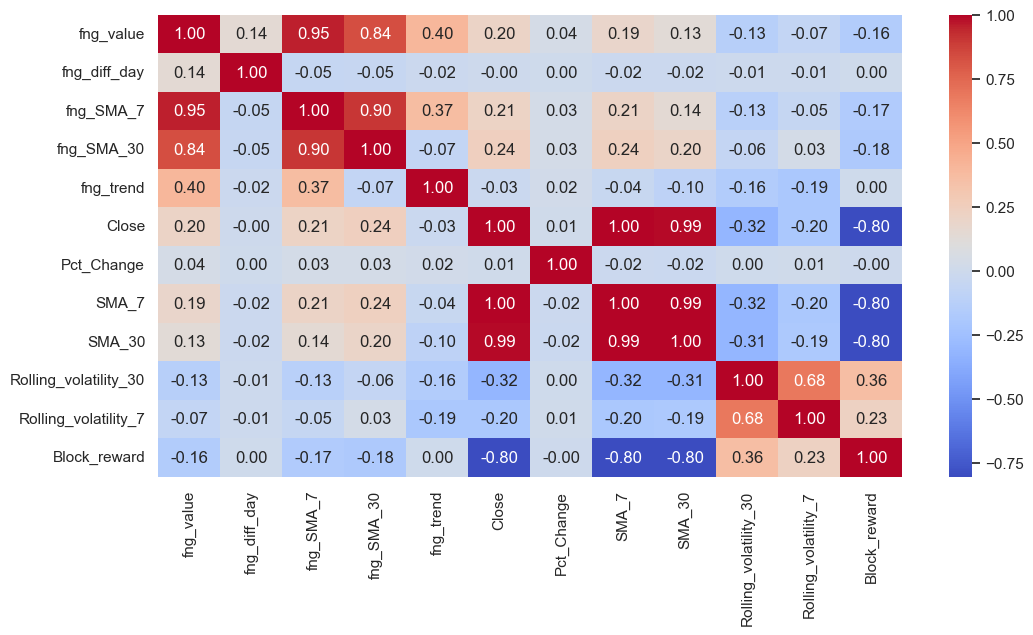

In [34]:
# Seleciono las columnas del indice F&G para hacer el mapa de calor (correlacion)
fng_cols = ['fng_value', 'fng_diff_day', 'fng_SMA_7', 'fng_SMA_30', 'fng_trend']

# Columnas de precio BTC relevantes
btc_cols = ['Close', 'Pct_Change', 'SMA_7', 'SMA_30', 'Rolling_volatility_30','Rolling_volatility_7', 'Block_reward',]

# Selecciono solo las columnas de interés
corr_data = full_data[fng_cols + btc_cols].dropna()

# Calculo la correlación
corr_matrix = corr_data.corr()

# Heatmap interactivo con plotly
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt=".2f")
fig = px.imshow(
    corr_matrix,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    title='Mapa de Calor - Correlación Fear & Greed vs BTC'
)
fig.show()

In [29]:
#Guardo el csv final para entrenal 
full_data.to_csv("../Data/full_data.csv",index=False)
full_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3127 entries, 0 to 3126
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   3127 non-null   datetime64[ns]
 1   Close                  3127 non-null   float64       
 2   Open                   3127 non-null   float64       
 3   High                   3127 non-null   float64       
 4   Low                    3127 non-null   float64       
 5   Volume                 3127 non-null   int64         
 6   Daily_Change           3127 non-null   float64       
 7   Volatility             3127 non-null   float64       
 8   Pct_Change             3126 non-null   float64       
 9   Volume_Change_pct      3126 non-null   float64       
 10  SMA_7                  3121 non-null   float64       
 11  SMA_30                 3098 non-null   float64       
 12  Rolling_volatility_7   3120 non-null   float64       
 13  Rol

In [35]:
full_data["Date"] = pd.to_datetime(full_data["Date"])  # asegurar tipo datetime
full_data= full_data.set_index("Date", drop=False)

**Visualización de tendencia en este último año**  
*SMA 7 encima de SMA 30 → tendencia alcista: el precio reciente está subiendo más rápido que la tendencia general.*   
*SMA 7 debajo de SMA 30 → tendencia bajista: el precio reciente está cayendo respecto a la tendencia general.*
    
Entre enero y marzo de 2026, el precio muestra una tendencia bajista marcada, cayendo desde un pico inicial superior a los 90 000 USD (tras el máximo del ciclo a fines del año pasado) hasta tocar un soporte crítico alrededor de los 60 000 USD.
Desde abril hasta mediados de mayo, se observa una fuerte recuperación temporal, con precios que logran repuntar con fuerza superando los 75 000 USD y buscando estabilizarse. 
En junio, el precio experimenta nuevos altibajos y una corrección que vuelve a testear la zona de soporte clave de los 60 000–65 000 USD, manteniendo al mercado a la expectativa.

*Cruce hacia arriba (SMA 7 cruza SMA 30 desde abajo): señal alcista y de compra potencial (“golden cross”).*  
*Cruce hacia abajo (SMA 7 cruza SMA 30 desde arriba): señal bajista y de venta potencial (“death cross”).*


**Tendencia actual (junio 2026):**: El precio consolida cerca del soporte de los 63 000 USD, mostrando divergencias alcistas leves en temporalidades diarias. La media móvil de 7 días intenta estabilizarse sobre la de 30 días, lo que sugiere indicios de recuperación a corto plazo si el volumen acompaña y logra superar con fuerza la resistencia inmediata de los 65 000 USD.

In [36]:
fig = go.Figure()

df_short = full_data[full_data['Date'] >= '2026-01-01']

# Precio de cierre BTC
fig.add_trace(go.Scatter(
    x=df_short['Date'],
    y=df_short['Close'],
    mode='lines',
    name='BTC Close',
    line=dict(color='black', width=2)
))

# SMA 7 días
fig.add_trace(go.Scatter(
    x=df_short['Date'],
    y=df_short['SMA_7'],
    mode='lines',
    name='SMA 7 días',
    line=dict(color='blue', width=2, dash='dash')
))

# SMA 30 días
fig.add_trace(go.Scatter(
    x=df_short['Date'],
    y=df_short['SMA_30'],
    mode='lines',
    name='SMA 30 días',
    line=dict(color='red', width=2, dash='dash')
))

# Layout
fig.update_layout(
    title="Precio de Bitcoin con Promedios Móviles (7 y 30 días) desde ene-2025 a hoy",
    xaxis_title="Fecha",
    yaxis_title="Precio USD",
    template="plotly_white",
    width=900,
    height=500,
    hovermode="x unified"
)

fig.show()

In [37]:
full_data.describe()


,Date,Close,Open,High,Low,Volume,Daily_Change,Volatility,Pct_Change,Volume_Change_pct,...,BTC_Close_t-3,BTC_Close_t-7,fng_value,fng_diff_day,fng_SMA_7,fng_SMA_30,fng_trend,fng_value_lag1,Is_Halving_Date,Block_reward
count,3127,3127.000000,3127.000000,3127.000000,3127.000000,3.127000e+03,3127.000000,3127.000000,3126.000000,3126.000000,...,3124.000000,3120.000000,3127.000000,3126.000000,3121.000000,3098.000000,3098.000000,3126.000000,3127.000000,3127.000000
mean,2022-05-14 00:00:00,40133.380424,40112.688172,40885.152031,39293.249236,3.079146e+10,20.692252,1591.902795,0.001232,0.054033,...,40097.113629,40057.073120,45.383754,0.019514,45.377992,45.421412,-0.042688,45.374920,0.000640,7.052486
min,2018-02-01 00:00:00,3236.761719,3236.274658,3275.377930,3191.303467,2.923670e+09,-10314.277344,18.922607,-0.371695,-0.869188,...,3236.761719,3236.761719,5.000000,-45.000000,7.428571,10.000000,-31.338095,5.000000,0.000000,3.125000
25%,2020-03-23 12:00:00,9758.411621,9758.768555,9957.440430,9581.794434,1.606121e+10,-343.422852,358.933594,-0.013355,-0.141702,...,9757.083740,9751.782227,26.000000,-3.000000,26.857143,28.366667,-5.122619,26.000000,0.000000,3.125000
50%,2022-05-14 00:00:00,30271.130859,30249.626953,30636.029297,29652.705078,2.688255e+10,6.625000,1056.181641,0.000624,-0.007800,...,30242.095703,30192.794922,44.000000,0.000000,43.714286,43.566667,0.097619,44.000000,0.000000,6.250000
75%,2024-07-03 12:00:00,63402.302734,63399.447266,64388.259766,62286.783203,4.036237e+10,391.706177,2333.427734,0.014913,0.175993,...,63346.060547,63317.255859,64.000000,3.000000,63.000000,61.658333,5.408333,64.000000,0.000000,12.500000
max,2026-08-24 00:00:00,124752.531250,124752.140625,126198.070312,123196.046875,3.509679e+11,8230.070312,17927.250000,0.187465,5.439003,...,124752.531250,124752.531250,95.000000,40.000000,94.000000,92.366667,27.123810,95.000000,1.000000,12.500000
std,NaN,32449.996498,32447.480546,32963.601880,31891.353442,2.169363e+10,1345.663323,1653.280714,0.032799,0.376666,...,32444.443098,32445.448429,22.046101,6.433110,21.275956,19.841762,9.212039,22.044091,0.025286,3.522039
